# 01 · Dataset Analysis and SFT Dataset Preparation

The dataset contains **13,891 Turkish questions**, each answered by both **GPT-4o** and **DeepSeek**, with a human label for which answer is better:

`1` GPT-4o better · `2` DeepSeek better · `3` both good · `4` both bad

This notebook:
1. Analyzes question and answer lengths
2. Looks at the preference-label distribution and the questions where both models failed
3. Builds two instruction-tuning datasets in JSONL format: `v1_dataset_gpt4o.jsonl` (question + GPT-4o answer) and `v2_dataset_deepseek.jsonl` (question + DeepSeek answer)
4. Compares the training loss curves of the four fine-tuning runs

In [9]:
import torch
import random
import time
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.manifold import TSNE
import seaborn as sns
import os
import gc
import json

In [3]:
# Create a directory for checkpoints
checkpoint_dir = "odev3_ha"
os.makedirs(checkpoint_dir, exist_ok=True)

## Load the dataset

In [7]:
import pandas as pd

# CSV link
csv_url = "https://docs.google.com/spreadsheets/d/1Woh-A5oTJ715ivgIsu6NCkdav_k46iqr/export?format=csv"

# Fetch data
df = pd.read_csv(csv_url)

# Look at a data sample
display(df.head())

,Soru,gpt4o cevabı,deepseek cevabı,"Hangisi iyi? (1: gpt4o daha iyi, 2: deepseek daha iyi, 3: ikisi de yeterince iyi, 4: ikisi de kötü)"
0,⦁\tŞu listedekilerin ortak özelliği nedir? Göz...,"Gözlük, kalem ve laptopun tek bir ortak özelli...","Şu listedeki öğelerin ortak özelliği:\nGözlük,...",4
1,"""Adalet"" kavramına benzer, ancak farklı toplum...","""Adalet"" kavramına benzer, ancak farklı toplum...","""Adalet"" gibi evrensel ancak yoruma açık diğer...",3
2,"""ali topu at"" ve ""kemal topu tut"" cümlelerinde...","""Ali topu at"" → 11 harf\n""Kemal topu tut"" → 16...","""Ali topu at"" (3+4+2) + ""Kemal topu tut"" (5+4+...",4
3,"""ali topu at"" ve ""kemal topu tut"" cümlelerinde...","""Ali"", ""top"", ""Kemal"" toplam 3 varlık vardır.","Varlıklar: Ali, top, Kemal → 3 varlık",3
4,"""Çekiç, tornavida, pense"" listesindeki tüm nes...","""Çekiç, tornavida, pense"" listesindeki tüm nes...","Bu nesnelerin ortak işlevi, elle tutularak fiz...",3


In [27]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13891 entries, 0 to 13890
Data columns (total 4 columns):
 #   Column                                                                                               Non-Null Count  Dtype 
---  ------                                                                                               --------------  ----- 
 0   Soru                                                                                                 13891 non-null  object
 1   gpt4o cevabı                                                                                         13891 non-null  object
 2   deepseek cevabı                                                                                      13891 non-null  object
 3   Hangisi iyi? (1: gpt4o daha iyi, 2: deepseek daha iyi, 3: ikisi de yeterince iyi, 4: ikisi de kötü)  13891 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 434.2+ KB


,"Hangisi iyi? (1: gpt4o daha iyi, 2: deepseek daha iyi, 3: ikisi de yeterince iyi, 4: ikisi de kötü)"
count,13891.000000
mean,2.411777
std,0.867816
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,4.000000


## Question and answer length statistics

In [31]:
df['soru_uzunlugu'] = df['Soru'].apply(lambda x: len(x.split()))
df['gpt4o_cevap_uzunlugu'] = df['gpt4o cevabı'].apply(lambda x: len(x.split()))
df['deepseek_cevap_uzunlugu'] = df['deepseek cevabı'].apply(lambda x: len(x.split()))

In [35]:
# Statistical summary
df[['soru_uzunlugu', 'gpt4o_cevap_uzunlugu', 'deepseek_cevap_uzunlugu']].describe()

,soru_uzunlugu,gpt4o_cevap_uzunlugu,deepseek_cevap_uzunlugu
count,13891.000000,13891.000000,13891.000000
mean,8.753797,79.691527,84.447628
std,5.274605,73.749189,84.454837
min,2.000000,1.000000,1.000000
25%,6.000000,18.000000,15.000000
50%,7.000000,63.000000,61.000000
75%,10.000000,127.000000,128.000000
max,120.000000,885.000000,1027.000000


In [37]:
(df['gpt4o_cevap_uzunlugu'] > df['deepseek_cevap_uzunlugu']).mean() * 100

51.65214887337125

### In 51.65% of the samples, GPT-4o's answer is longer than DeepSeek's.

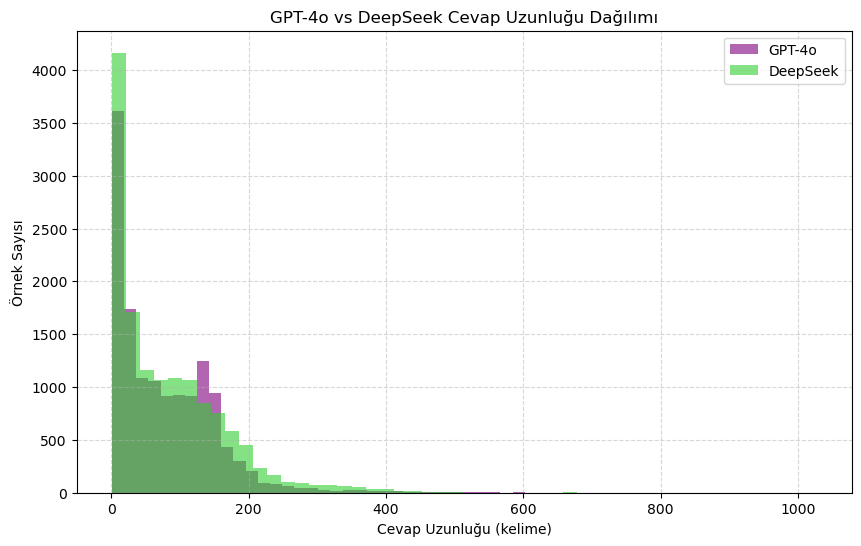

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df['gpt4o_cevap_uzunlugu'], bins=50, alpha=0.6, label='GPT-4o', color='purple')
plt.hist(df['deepseek_cevap_uzunlugu'], bins=50, alpha=0.6, label='DeepSeek', color='limegreen')
plt.xlabel('Cevap Uzunluğu (kelime)')
plt.ylabel('Örnek Sayısı')
plt.title('GPT-4o vs DeepSeek Cevap Uzunluğu Dağılımı')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Human preference labels

In [48]:
# Distribution of the "which is better?" column
label_counts = df['Hangisi iyi? (1: gpt4o daha iyi, 2: deepseek daha iyi, 3: ikisi de yeterince iyi, 4: ikisi de kötü)'].value_counts().sort_index()

# Show as percentages too
label_percentages = df['Hangisi iyi? (1: gpt4o daha iyi, 2: deepseek daha iyi, 3: ikisi de yeterince iyi, 4: ikisi de kötü)'].value_counts(normalize=True).sort_index() * 100

# Show results
print("Sayılar:\n", label_counts)
print("\nYüzdeler (%):\n", label_percentages)

Sayılar:
 Hangisi iyi? (1: gpt4o daha iyi, 2: deepseek daha iyi, 3: ikisi de yeterince iyi, 4: ikisi de kötü)
1    2835
2    3214
3    7129
4     713
Name: count, dtype: int64

Yüzdeler (%):
 Hangisi iyi? (1: gpt4o daha iyi, 2: deepseek daha iyi, 3: ikisi de yeterince iyi, 4: ikisi de kötü)
1    20.408898
2    23.137283
3    51.320999
4     5.132820
Name: proportion, dtype: float64


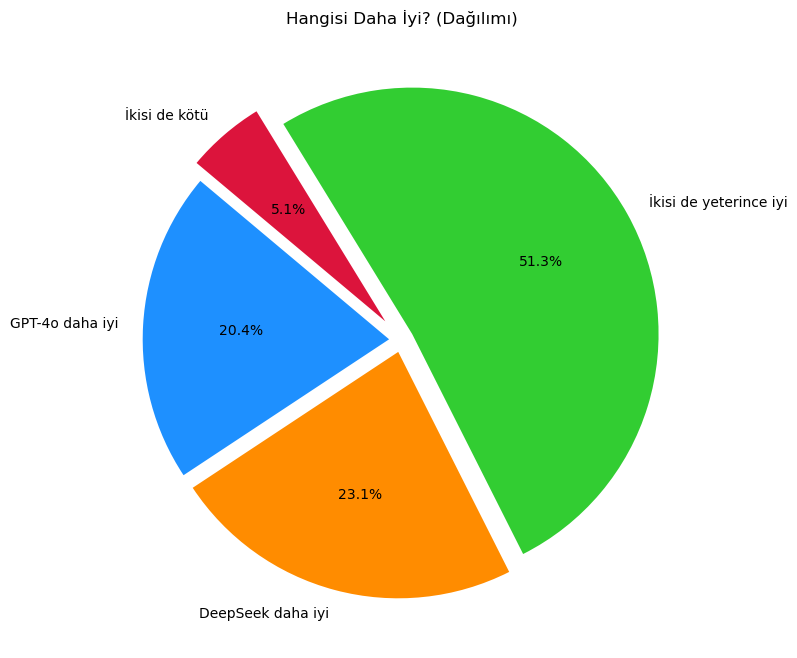

In [52]:
import matplotlib.pyplot as plt

labels = ['GPT-4o daha iyi', 'DeepSeek daha iyi', 'İkisi de yeterince iyi', 'İkisi de kötü']
sizes = label_counts.values
colors = ['dodgerblue', 'darkorange', 'limegreen', 'crimson']

plt.figure(figsize=(8,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=[0.05,0.05,0.05,0.1])
plt.title('Hangisi Daha İyi? (Dağılımı)')
plt.show()

## Questions where both models failed (label 4)

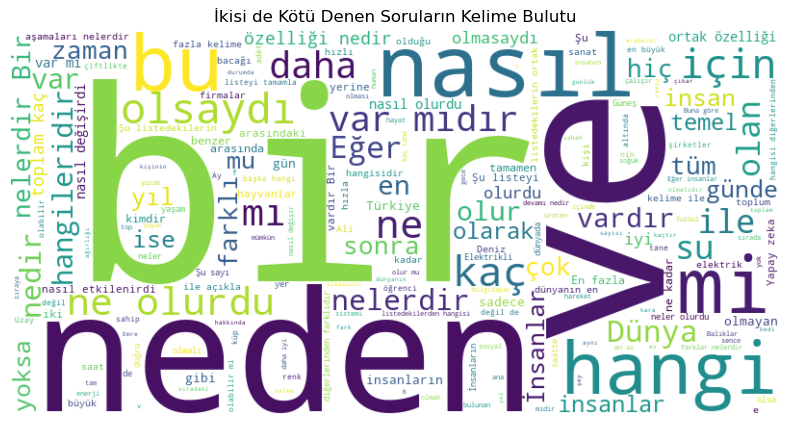

In [62]:
kotu_df = df[df['Hangisi iyi? (1: gpt4o daha iyi, 2: deepseek daha iyi, 3: ikisi de yeterince iyi, 4: ikisi de kötü)'] == 4]
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(kotu_df['Soru'].tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("İkisi de Kötü Denen Soruların Kelime Bulutu")
plt.show()

In [64]:
kotu_df['kategori'] = kotu_df['Soru'].apply(lambda x: 
    'matematik' if 'kaç' in x or 'topla' in x or 'böl' in x else
    'tarih' if 'tarih' in x or 'ne zaman' in x else
    'programlama' if 'kod' in x or 'python' in x else
    'genel'
)
kotu_df['kategori'].value_counts()

kategori
genel          633
matematik       71
tarih            8
programlama      1
Name: count, dtype: int64

## Build instruction-tuning datasets (JSONL)

In [11]:
# 2. V1 dataset: (question + GPT-4o answer)
v1_dataset = []

for idx, row in df.iterrows():
    soru = row['Soru']   # column name must be 'Soru' (question)
    cevap = row['gpt4o cevabı']  # same here: exact column name matters
    
    # Skip if question or answer is missing
    if pd.isna(soru) or pd.isna(cevap):
        continue
    
    entry = {
        "prompt": soru,
        "response": cevap
    }
    v1_dataset.append(entry)

# 3. Save to file
with open("v1_dataset_gpt4o.jsonl", "w", encoding="utf-8") as f:
    for item in v1_dataset:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"{len(v1_dataset)} adet örnek başarıyla v1_dataset_gpt4o.jsonl dosyasına yazıldı!")

13891 adet örnek başarıyla v1_dataset_gpt4o.jsonl dosyasına yazıldı!


In [13]:
# 1. V2 dataset: (question + DeepSeek answer)
v2_dataset = []

for idx, row in df.iterrows():
    soru = row['Soru']
    cevap = row['deepseek cevabı']
    
    # Skip if question or answer is missing
    if pd.isna(soru) or pd.isna(cevap):
        continue
    
    entry = {
        "prompt": soru,
        "response": cevap
    }
    v2_dataset.append(entry)

# 2. Save to file
with open("v2_dataset_deepseek.jsonl", "w", encoding="utf-8") as f:
    for item in v2_dataset:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"{len(v2_dataset)} adet örnek başarıyla v2_dataset_deepseek.jsonl dosyasına yazıldı!")

13891 adet örnek başarıyla v2_dataset_deepseek.jsonl dosyasına yazıldı!


In [21]:
from datasets import load_dataset

dataset_gpt = load_dataset("json", data_files="v1_dataset_gpt4o.jsonl", split="train")

# Dataset sample
print(dataset_gpt[0])

{'prompt': '⦁\tŞu listedekilerin ortak özelliği nedir? Gözlük, Kalem, Laptop', 'response': 'Gözlük, kalem ve laptopun tek bir ortak özelliği, hepsinin **kişisel kullanım için tasarlanmış** olmalarıdır. Bu araçlar, bireylerin günlük yaşamlarında kişisel ihtiyaçlarını karşılamak için kullanılır.'}


## Training loss comparison of the four runs
Loss values logged every 10 steps during training (`full_training_loss_comparison.csv`).

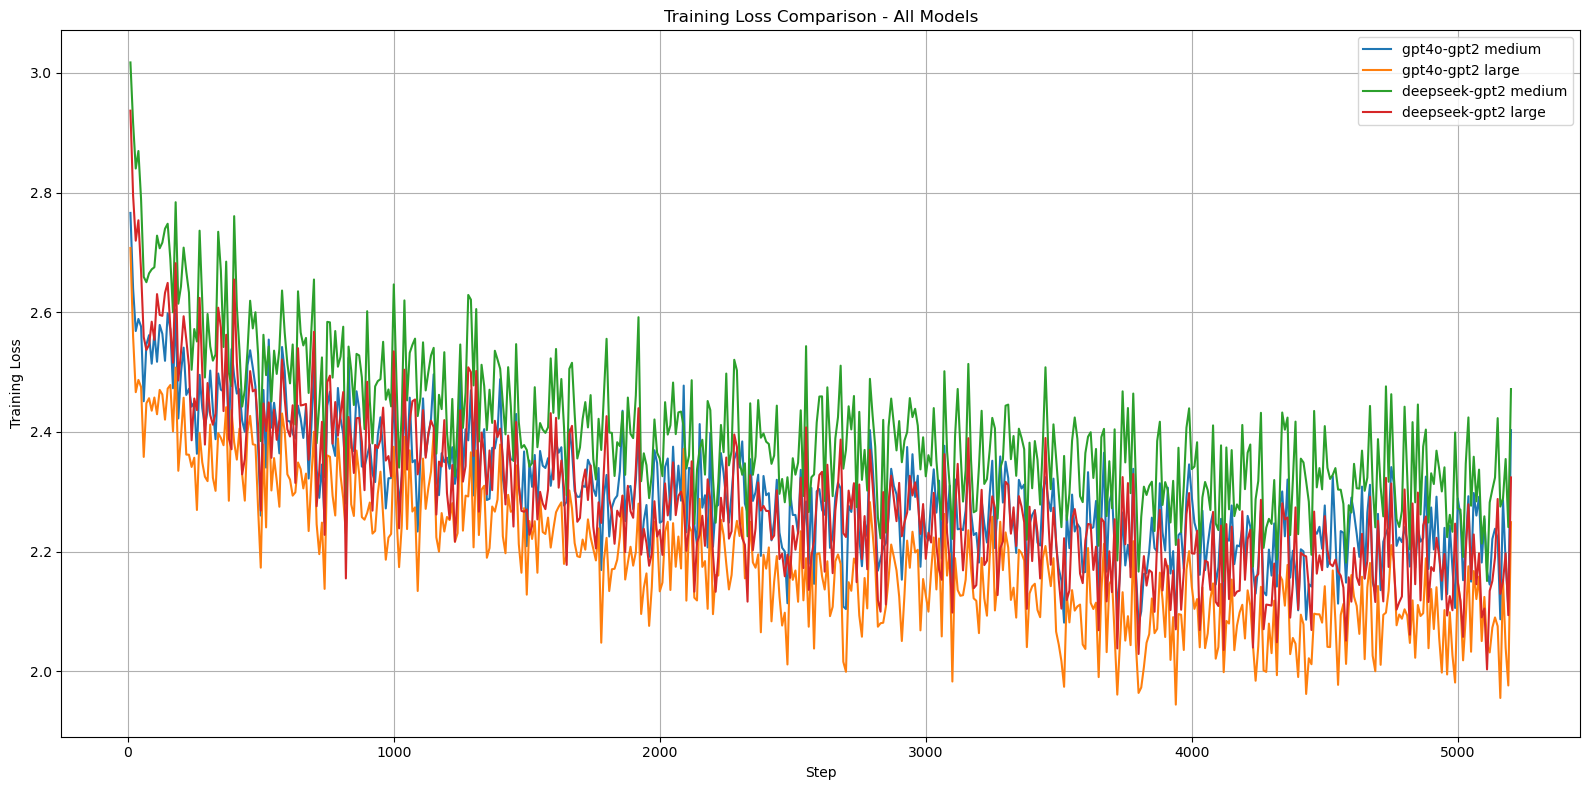

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv("full_training_loss_comparison.csv")

# Plot
plt.figure(figsize=(16, 8))

plt.plot(df["Step"], df["Training Loss gpt4o-gpt2 medium"], label="gpt4o-gpt2 medium")
plt.plot(df["Step"], df["Training Loss gpt4o-gpt2 large"], label="gpt4o-gpt2 large")
plt.plot(df["Step"], df["Training Loss deepseek-gpt2 medium"], label="deepseek-gpt2 medium")
plt.plot(df["Step"], df["Training Loss deepseek-gpt2 large"], label="deepseek-gpt2 large")

plt.title("Training Loss Comparison - All Models")
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


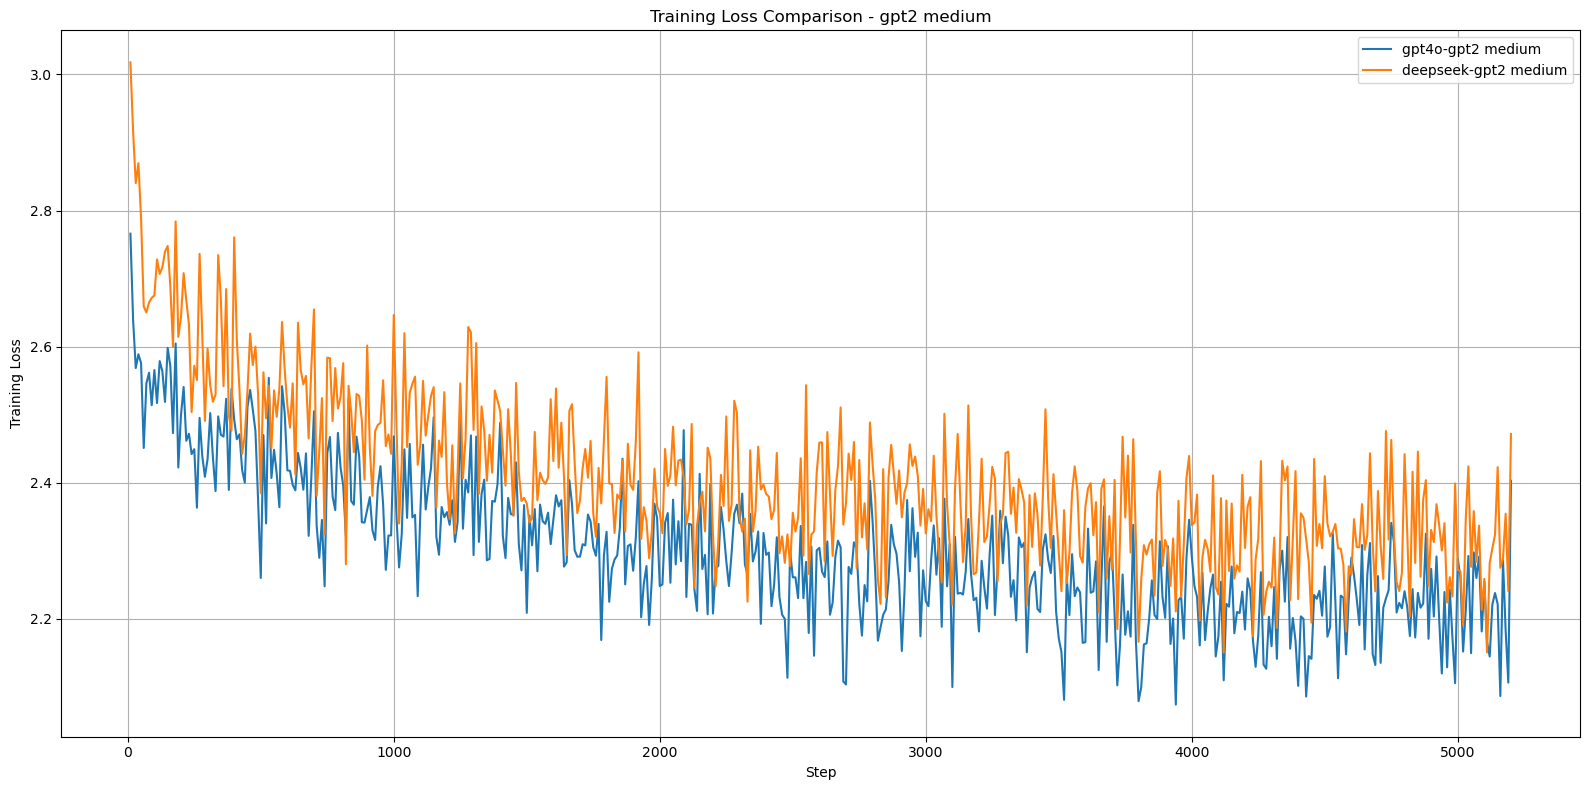

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv("full_training_loss_comparison.csv")

# Plot
plt.figure(figsize=(16, 8))

plt.plot(df["Step"], df["Training Loss gpt4o-gpt2 medium"], label="gpt4o-gpt2 medium")
# plt.plot(df["Step"], df["Training Loss gpt4o-gpt2 large"], label="gpt4o-gpt2 large")
plt.plot(df["Step"], df["Training Loss deepseek-gpt2 medium"], label="deepseek-gpt2 medium")
# plt.plot(df["Step"], df["Training Loss deepseek-gpt2 large"], label="deepseek-gpt2 large")

plt.title("Training Loss Comparison - gpt2 medium")
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

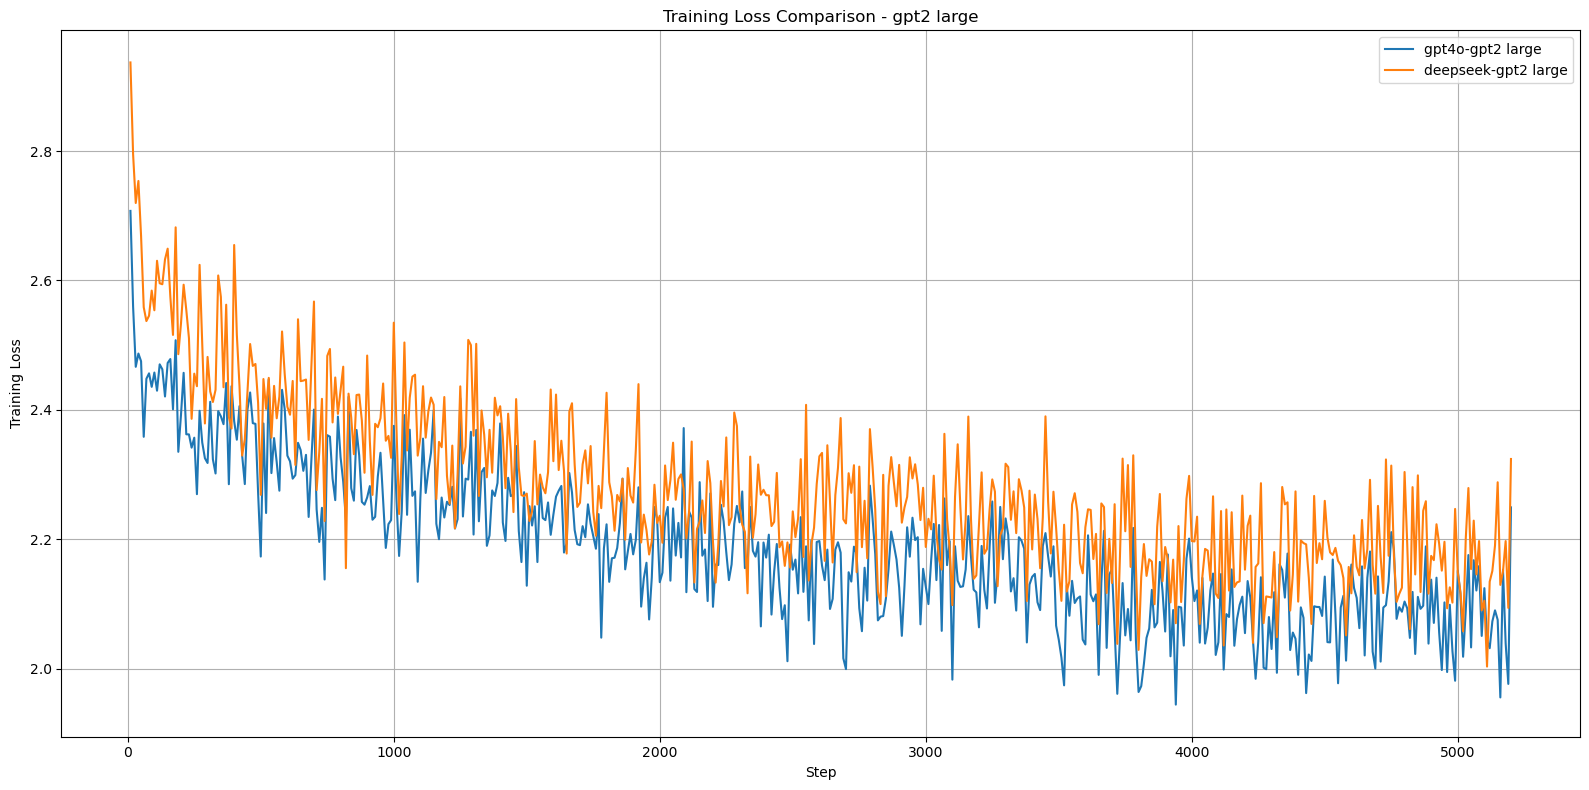

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv("full_training_loss_comparison.csv")

# Plot
plt.figure(figsize=(16, 8))

# plt.plot(df["Step"], df["Training Loss gpt4o-gpt2 medium"], label="gpt4o-gpt2 medium")
plt.plot(df["Step"], df["Training Loss gpt4o-gpt2 large"], label="gpt4o-gpt2 large")
# plt.plot(df["Step"], df["Training Loss deepseek-gpt2 medium"], label="deepseek-gpt2 medium")
plt.plot(df["Step"], df["Training Loss deepseek-gpt2 large"], label="deepseek-gpt2 large")

plt.title("Training Loss Comparison - gpt2 large")
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

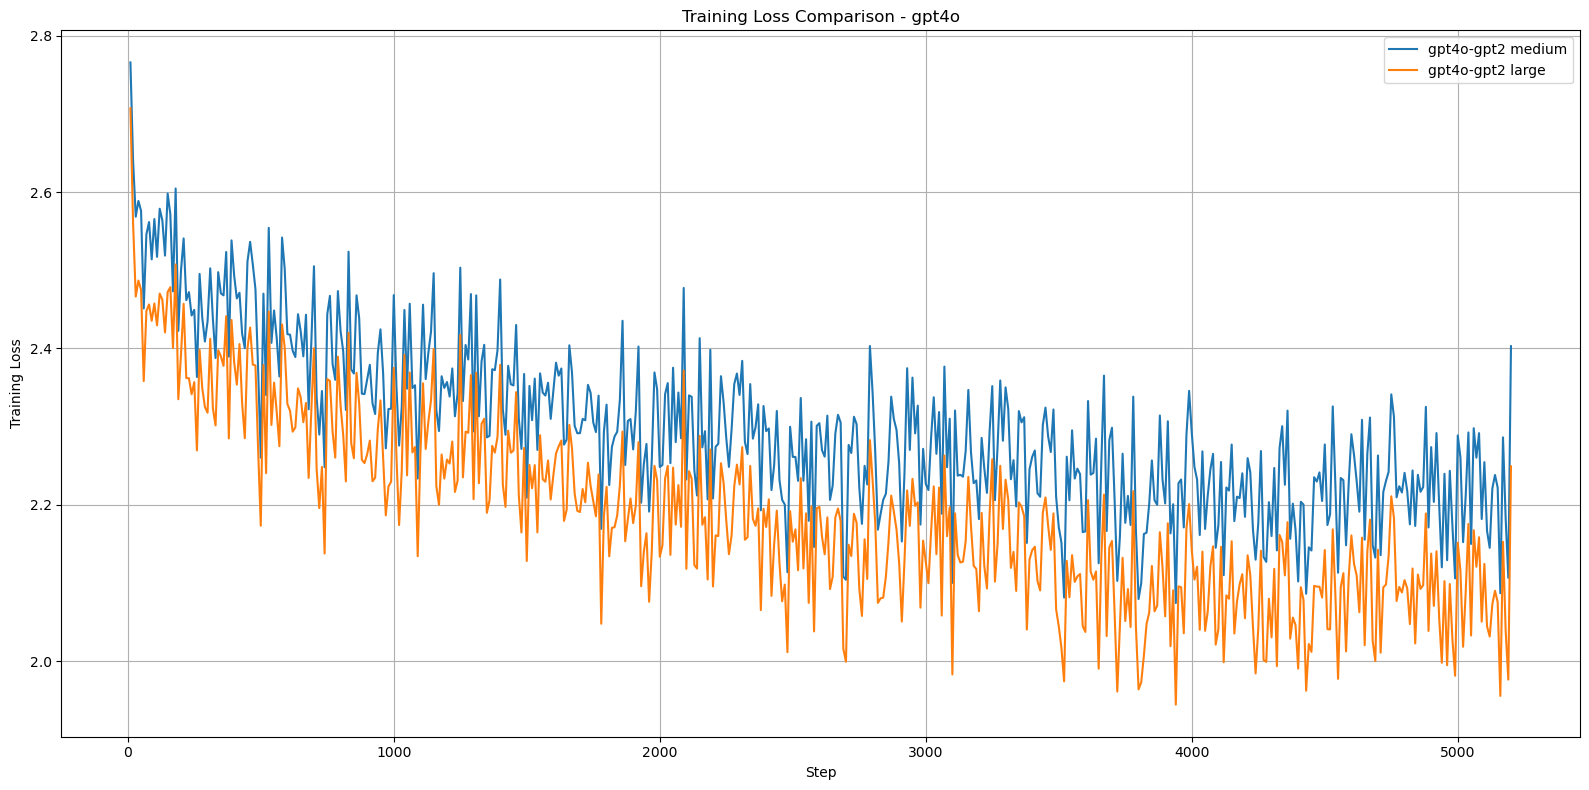

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv("full_training_loss_comparison.csv")

# Plot
plt.figure(figsize=(16, 8))

plt.plot(df["Step"], df["Training Loss gpt4o-gpt2 medium"], label="gpt4o-gpt2 medium")
plt.plot(df["Step"], df["Training Loss gpt4o-gpt2 large"], label="gpt4o-gpt2 large")
# plt.plot(df["Step"], df["Training Loss deepseek-gpt2 medium"], label="deepseek-gpt2 medium")
# plt.plot(df["Step"], df["Training Loss deepseek-gpt2 large"], label="deepseek-gpt2 large")

plt.title("Training Loss Comparison - gpt4o")
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

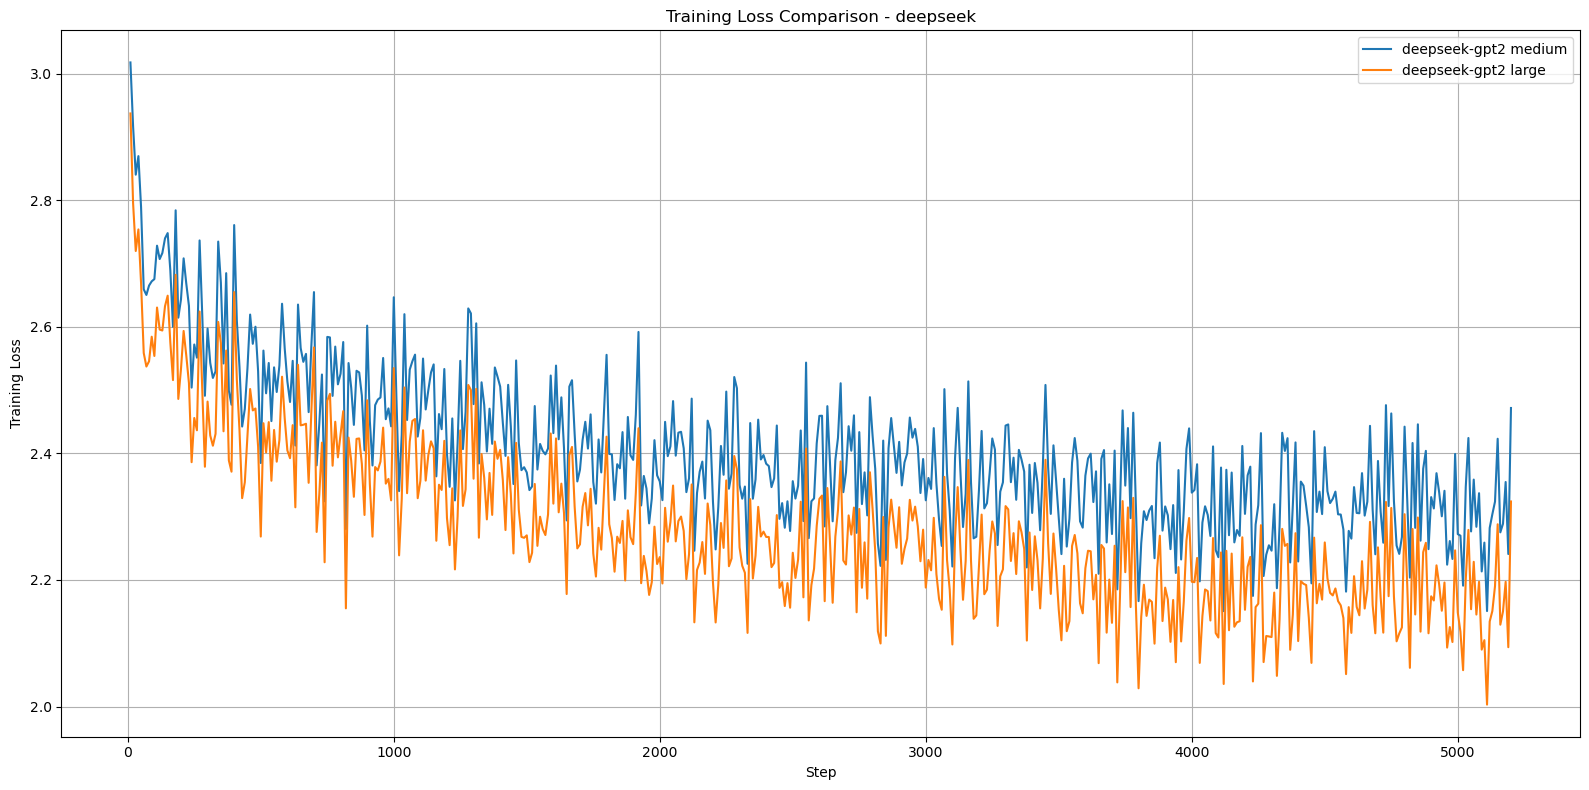

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv("full_training_loss_comparison.csv")

# Plot
plt.figure(figsize=(16, 8))

# plt.plot(df["Step"], df["Training Loss gpt4o-gpt2 medium"], label="gpt4o-gpt2 medium")
# plt.plot(df["Step"], df["Training Loss gpt4o-gpt2 large"], label="gpt4o-gpt2 large")
plt.plot(df["Step"], df["Training Loss deepseek-gpt2 medium"], label="deepseek-gpt2 medium")
plt.plot(df["Step"], df["Training Loss deepseek-gpt2 large"], label="deepseek-gpt2 large")

plt.title("Training Loss Comparison - deepseek")
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()